# Augmentation phase (**optional**)

In this augmentation phase we will visualize some augmenation options to help you make more informed decisitions in case you want to **adapt the default augmentation parameters** to your dataset.

You can always skip this part and go with the default parameters but if you have a limited datase or have any other motivation to apply augmentaiton, you should consider spending five minutes running this analysis.

## 1.0 DEMO version of your own? 

### Demo version

In [15]:
conf_path = "../etc/demo-config.yaml"
DEMO=True

### other model

In [20]:
conf_path = "../etc/config.yaml"
DEMO=False

# Image augmentation(**optional**)


In [27]:

import os
import matplotlib.pylab as plt
from tqdm import tqdm
import planktonclas
from planktonclas import paths, config
from planktonclas.data_utils import load_image, load_data_splits, augment ,create_data_splits ,create_data_splits
import numpy as np

import yaml
with open(conf_path, 'r') as f:
    CONF = yaml.safe_load(f)

CONF = config.get_conf_dict(CONF)


splits_dir = paths.get_splits_dir()


# #if using DEMO
if not DEMO:
    CONF['general']['images_directory']="../data/images"

if 'train.txt' not in os.listdir(splits_dir ):
    if not (CONF['dataset']['split_ratios']):
        if (CONF['training']['use_validation']) & (CONF['testing']['use_test']):
            split_ratios=[0.7,0.15,0.15]
        elif (CONF['training']['use_validation']) & (~CONF['testing']['use_test']):
            split_ratios=[0.9,0.1,0]
        else:
            split_ratios=[1,0,0]
    else:
        split_ratios=(CONF['dataset']['split_ratios'])
    create_data_splits(splits_dir=splits_dir,
                                    im_dir=CONF['general']['images_directory'],
                                    split_ratios=split_ratios)
        



# Load the training data
X_train, y_train = load_data_splits(splits_dir=splits_dir,
                                    im_dir=CONF['general']['images_directory'],
                                    split_name='train')




Loading train data...


In [28]:
X_train

array(['../data/images\\Actinoptychus/ecotaxa_Actinoptychus_0A287917-C897-49F5-8CBF-633895467766.jpg',
       '../data/images\\Actinoptychus/ecotaxa_Actinoptychus_00D9D0C4-D41A-42E8-9FA2-6F9985B39865.jpg',
       '../data/images\\Actinoptychus/ecotaxa_Actinoptychus_0A02C03F-CE0F-420C-8325-8F1AC79B5F63.jpg',
       '../data/images\\Actinoptychus/ecotaxa_Actinoptychus_0AB4C8AB-018E-4586-80FF-82322C376678.jpg',
       '../data/images\\Actinoptychus/ecotaxa_Actinoptychus_0A6A182E-69D1-4136-B332-CCB4BD8B0EDB.jpg',
       '../data/images\\Actinoptychus/ecotaxa_Actinoptychus_0AB28ACD-9394-4E08-8731-22BB01D27C39.jpg',
       '../data/images\\Actinoptychus/ecotaxa_Actinoptychus_0A4655A3-123D-4A0A-A55F-3302620763B6.jpg',
       '../data/images\\Actinoptychus/ecotaxa_Actinoptychus_0C7D68E8-D1F4-4D4B-A950-34E5BA82CA51.jpg',
       '../data/images\\Actinoptychus/ecotaxa_Actinoptychus_0A3E62B8-620B-4B38-8E11-149A509315CC.jpg',
       '../data/images\\Actinoptychus/ecotaxa_Actinoptychus_0CF14865-679E


    Perform data augmentation on some image using the albumentations package.

    Parameters
    ----------
    im : Numpy array
    params : dict or None
        Contains the data augmentation parameters
        Mandatory keys:
        - h_flip ([0,1] float): probability of performing an horizontal left-right mirroring.
        - v_flip ([0,1] float): probability of performing an vertical up-down mirroring.
        - rot ([0,1] float):  probability of performing a rotation to the image.
        - rot_lim (int):  max degrees of rotation.
        - stretch ([0,1] float):  probability of randomly stretching an image.
        - crop ([0,1] float): randomly take an image crop.
        - zoom ([0,1] float): random zoom applied to crop_size.
            --> Therefore the effective crop size at each iteration will be a
                random number between 1 and crop*(1-zoom). For example:
                  * crop=1, zoom=0: no crop of the image
                  * crop=1, zoom=0.1: random 

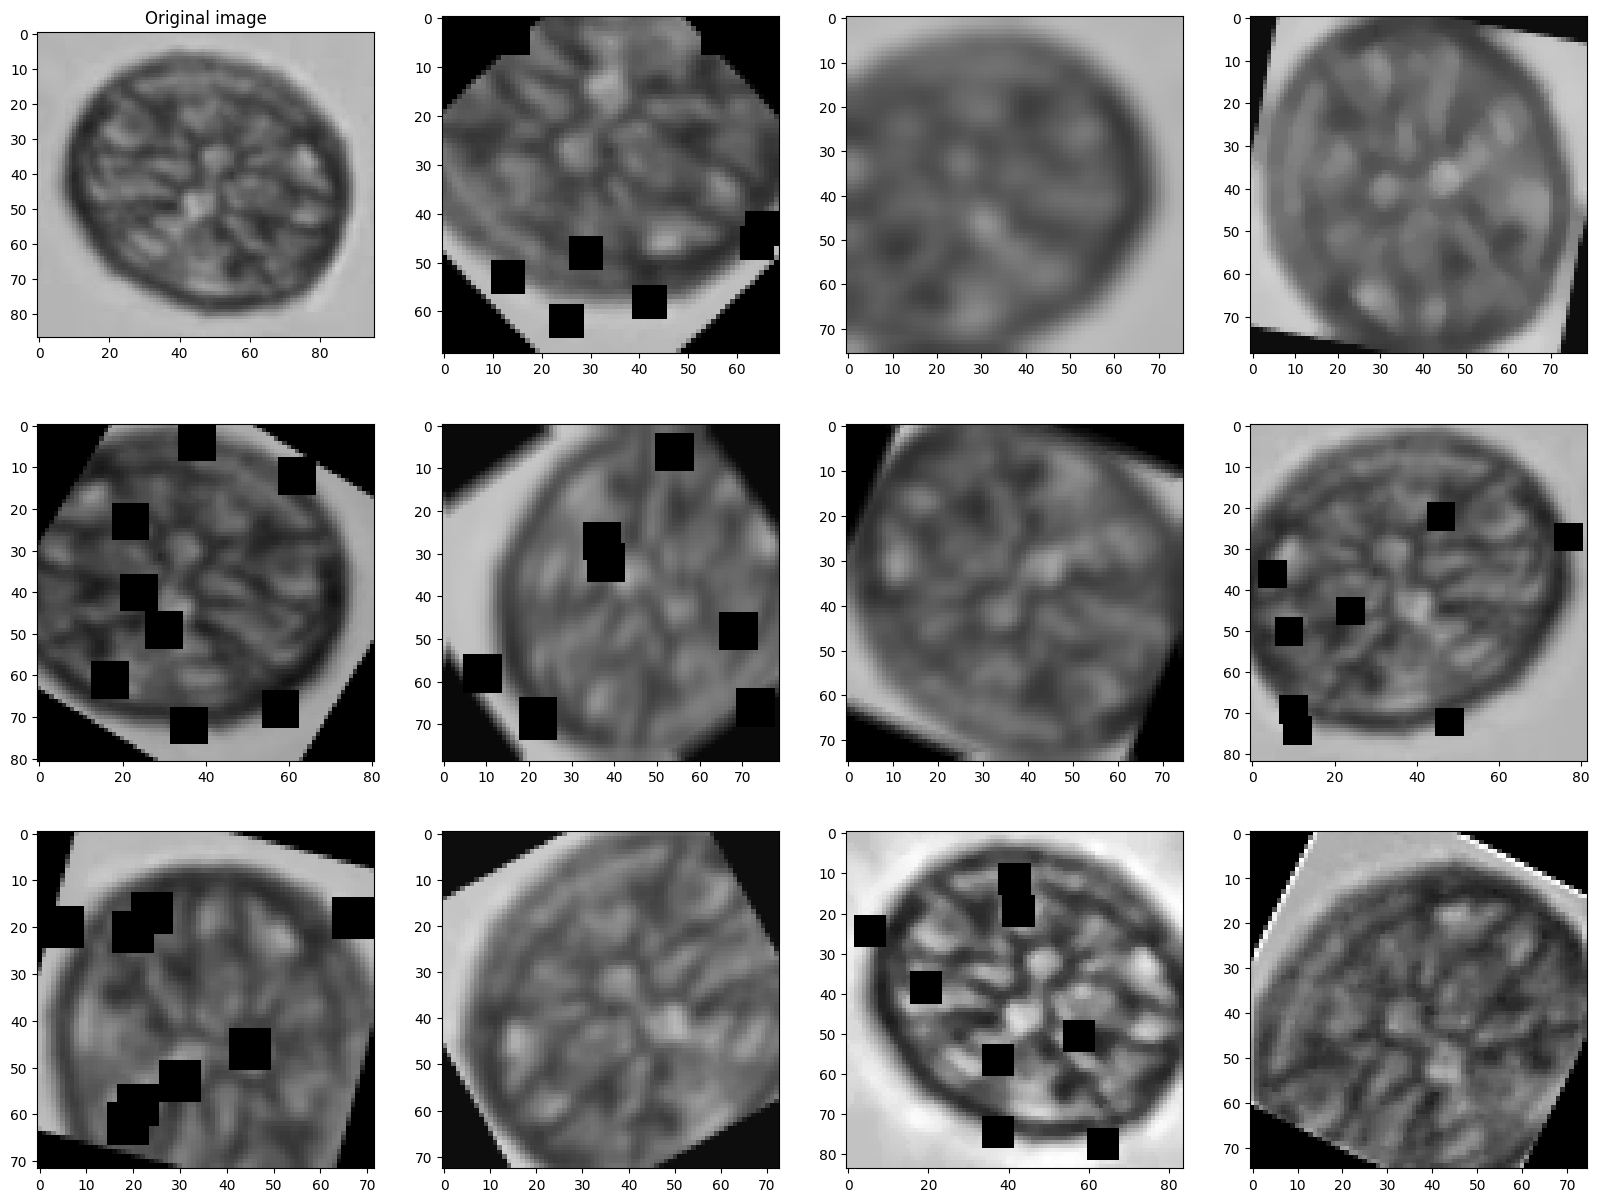

In [29]:
# Select the augmentation type
aug_params = CONF['augmentation']['train_mode'] #you can also try 'test_mode'

# You can also use your custom parameter to try different augmentations
aug_params = {'h_flip': 0.5,
              'v_flip': 0.5,
              'rot': 0.7,
              'rot_lim': 90,
              'stretch': 0.,
              'crop': 1.0,
              'zoom': 0.2,
              'blur': 0.3,
              'pixel_noise': 0.3,
              'pixel_sat': 0.3,
              'cutout': 0.5}

print(augment.__doc__)

fig, axs = plt.subplots(3,4, figsize=(20,15))
axs = axs.flatten()

# Plot original image
img = load_image(X_train[0])
axs[0].imshow(np.array(img).astype(np.uint8))
axs[0].set_title('Original image')

# Plot different examples of data augmentation
for i in range(11):
    img_aug = augment(img, params=aug_params)
    axs[i+1].imshow(np.array(img_aug).astype(np.uint8))